# CNN

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


# fashion MNIST 데이터를 다운받습니다.
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

I0000 00:00:1784612935.169627   64840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784612935.533134   64840 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784612937.320270   64840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [3]:
# 피쳐 스케일링
# 0 ~ 1 범위로 만듭니다.
x_train = np.reshape(x_train / 255, (-1, 28, 28, 1))
x_test = np.reshape(x_test / 255, (-1, 28, 28, 1))

In [ ]:
# 총 60000개 데이터 / 해상도 28*28 / 색깔 1
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [5]:
y_train[:5]

array([9, 0, 0, 3, 0], dtype=uint8)

In [ ]:
# 정답(타켓) 레이블링
# 각 데이터의 레이블을 범주형 형태로 변경합니다.(원-핫 인코딩)
# 전체 0부터 9까지 총 10개의 카테고리가 존재함
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [7]:
y_train[3]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [9]:
# 검증 데이터셋을 만듭니다.
from sklearn.model_selection import train_test_split

# 훈련/검증 데이터를 0.7/0.3의 비율로 분리합니다.
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                  test_size = 0.3, random_state = 777)

# 모델 구성
## ConV2D, MaxPool2D, Dense 층으로 구성

In [10]:
x_train.shape[1:]

(28, 28, 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten

# 이전과 다르게 리스트 형태로 층을 구성해볼 수 있습니다.
model = Sequential([
    # 항상 모델의 첫 번째 층은 입력의 형태를 명시해주어야 합니다.
    # 입력받을 때 1차원 벡터로 받지 않고 28*28 그대로 입력받음
    Conv2D(filters = 16, kernel_size = 3, strides = (1, 1),
           padding = 'same', activation = 'relu', input_shape = (28, 28, 1)),
    MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'),
    Conv2D(filters = 32, kernel_size = 3, strides = (1, 1),
           padding = 'same', activation = 'relu'),
    MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'),
    Conv2D(filters = 64, kernel_size = 3, strides = (1, 1),
           padding = 'same', activation = 'relu'),
    MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'),

    Flatten(), # Dense 층에 입력하기 위해 데이터를 펼쳐줍니다.
    Dense(64, activation = 'relu'),
    Dense(10, activation = 'softmax') # 10개의 출력을 가지는 신경망
])

/home/siwonl0508/ENTER/envs/deepl_tensor/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784614487.403264   64840 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])

history = model.fit(x_train, y_train,
                    epochs = 30,
                    batch_size = 32,
                    validation_data = (x_val, y_val))

Epoch 1/30


I0000 00:00:1784614596.365840  417249 service.cc:153] XLA service 0x73c1ac015a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784614596.365889  417249 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1784614596.428522  417249 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784614596.680594  417249 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1784614596.706148  417249 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1996__.43


  22/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.2670 - loss: 2.1249 

I0000 00:00:1784614603.224818  417249 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8078 - loss: 0.5222

I0000 00:00:1784614610.997045  417243 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1996__.43


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.8079 - loss: 0.5222 - val_acc: 0.8643 - val_loss: 0.3777
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.8804 - loss: 0.3296 - val_acc: 0.8948 - val_loss: 0.2983
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.8969 - loss: 0.2806 - val_acc: 0.8999 - val_loss: 0.2792
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - acc: 0.9076 - loss: 0.2503 - val_acc: 0.9007 - val_loss: 0.2738
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9171 - loss: 0.2256 - val_acc: 0.9154 - val_loss: 0.2436
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.9257 - loss: 0.2025 - val_acc: 0.9102 - val_loss: 0.2513
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.9319 - loss: 0.1854 - val_acc: 0.9158 - val_loss: 0.2414
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9358 - loss: 0.1690 - val_acc: 0.9154 - val_loss: 0.2487
Epoch 9/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 

# 모델 구조 확인하기

In [13]:
model.summary() # 모델의 구조를 확인합니다.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,640 (1.02 MB)

 Trainable params: 89,546 (349.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,094 (699.59 KB)

# plot model 함수를 사용

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model, './model.png', show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# 모델 평가 및 시각화
## 기존 Dense 층은 87% 효과

In [17]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9031 - loss: 0.5951


[0.5951002240180969, 0.9031000137329102]

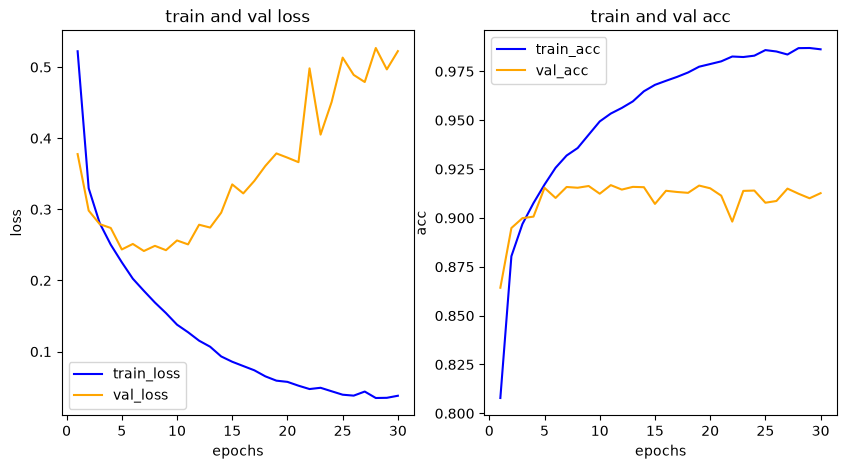

In [18]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss'] # 검증 데이터가 있는 경우 ‘val_’ 수식어가 붙습니다.

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()